# ============================================================
# EXTENDED ISOLATION FOREST — ENTRENAMIENTO CON OPTUNA
# Paper: media + 3*std como umbral
# Agregación por experimento completo
# ============================================================

In [ ]:

# ============================================================
# 0. INSTALACIÓN
# ============================================================

!pip install h2o optuna optuna-dashboard plotly seaborn

In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import h2o
from h2o.estimators import H2OExtendedIsolationForestEstimator
import optuna
from optuna.trial import TrialState
import optuna.visualization as vis
import numpy as np
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "browser"

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

RUTA_FEATURES   = "features"
CSV_INDEX       = "Motor_DB/index/master_index.csv"
RUTA_RESULTADOS = "resultados"
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

N_TRIALS    = 500
SEED        = 42
N_FEATURES  = 48
EXT_MAX     = N_FEATURES - 1  # 23


In [3]:
# ============================================================
# 3. INICIALIZAR H2O
# ============================================================

h2o.init(
    nthreads=-1,       # usa todos los cores disponibles
    max_mem_size="10G"  # ajusta según tu RAM
)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "21.0.10" 2026-01-20; OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-124.04); OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-124.04, mixed mode, sharing)
  Starting server from /home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp4lp4acrz
  JVM stdout: /tmp/tmp4lp4acrz/h2o_ariel_started_from_python.out
  JVM stderr: /tmp/tmp4lp4acrz/h2o_ariel_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 28 days
H2O_cluster_name:,H2O_from_python_ariel_ihwew1
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,9.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [4]:
# ============================================================
# 4. CARGAR DATOS
# ============================================================

print("Cargando datos...\n")

index = pd.read_csv(CSV_INDEX)

train    = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val      = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano = h2o.import_file(os.path.join(RUTA_FEATURES, "test", "sano.csv"))

fallos_frames = {}
carpeta_test  = os.path.join(RUTA_FEATURES, "test")
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_frames[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

print(f"Train     : {train.shape[0]} ventanas ({train.shape[0]//100} experimentos)")
print(f"Val sano  : {val.shape[0]} ventanas ({val.shape[0]//100} experimentos)")
print(f"Test sano : {test_sano.shape[0]} ventanas ({test_sano.shape[0]//100} experimentos)")
print(f"Grupos de fallo: {len(fallos_frames)}")

Cargando datos...

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |██████████████

In [5]:
# ============================================================
# 5. FUNCIÓN DE AGREGACIÓN POR EXPERIMENTO
# ============================================================

def agregar_por_experimento(scores_array, ventanas_por_exp):
    """
    Divide los scores en experimentos de ventanas_por_exp ventanas
    y devuelve la mediana de cada experimento.
    Si el experimento tiene distinto nº de ventanas, usa todas.
    """
    medianas = []
    n = len(scores_array)
    for i in range(0, n, ventanas_por_exp):
        grupo = scores_array[i:i + ventanas_por_exp]
        if len(grupo) > 0:
            medianas.append(np.median(grupo))
    return np.array(medianas)

def agregar_por_experimento_variable(scores_array, n_archivos):
    """
    Para grupos con distinto nº de ventanas por experimento,
    divide equitativamente el total entre n_archivos.
    """
    n = len(scores_array)
    ventanas_por_exp = n // n_archivos
    return agregar_por_experimento(scores_array, ventanas_por_exp)

In [6]:
# ============================================================
# 6. FUNCIÓN OBJETIVO OPTUNA
# ============================================================

def objective(trial):

    ntrees          = trial.suggest_int("ntrees",          100, 800)
    sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)
    extension_level = trial.suggest_int("extension_level", 0,   EXT_MAX)

    model = H2OExtendedIsolationForestEstimator(
        ntrees          = ntrees,
        sample_size     = sample_size,
        extension_level = extension_level,
        seed            = SEED
    )
    
    try:
        model.train(training_frame=train)
    except Exception as e:
        print(f"  Trial fallido por memoria: ntrees={ntrees}, sample_size={sample_size} → {e}")
        raise optuna.exceptions.TrialPruned()  # Optuna lo descarta y continúa

    # Scores de train y val
    scores_train = model.predict(train)["anomaly_score"].as_data_frame().values.flatten()
    scores_val   = model.predict(val)["anomaly_score"].as_data_frame().values.flatten()

    # Agregar por experimento (100 ventanas = 1 experimento)
    medianas_train = agregar_por_experimento(scores_train, 100)
    medianas_val   = agregar_por_experimento(scores_val,   100)

    # Combinar train + val
    medianas_total = np.concatenate([medianas_train, medianas_val])

    # Umbral = media + 3*std  (paper)
    media = np.mean(medianas_total)
    std   = np.std(medianas_total)
    umbral = media + 3 * std

    trial.set_user_attr("media",  round(float(media),  6))
    trial.set_user_attr("std",    round(float(std),    6))
    trial.set_user_attr("umbral", round(float(umbral), 6))

    return umbral  # minimizar el umbral

In [ ]:
h2o.cluster().show_status()  # verificar que H2O sigue vivo

In [7]:
# ============================================================
# 7. OPTIMIZACIÓN
# ============================================================

print("\n" + "="*60)
print(f"Iniciando optimización: {N_TRIALS} trials")
print("="*60 + "\n")

sampler = optuna.samplers.TPESampler(seed=SEED)
study   = optuna.create_study(
    direction  = "minimize",
    sampler    = sampler,
    storage    = "sqlite:///resultados/optuna_eif.db",
    study_name = "EIF_motores_v3_48features",
    load_if_exists = True
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)


Iniciando optimización: 500 trials



[I 2026-05-11 09:45:32,587] A new study created in RDB with name: EIF_motores_v3_48features
  0%|          | 0/500 [00:00<?, ?it/s]

extendedisolationforest Model Build progress: |

/tmp/ipykernel_14891/2152914917.py:8: UserWarning: The distribution is specified by [256, 1060] and step=64, but the range is not divisible by `step`. It will be replaced with [256, 1024].
  sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)


██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

...

███████████████████████████████████| (done) 100%
[I 2026-05-11 10:15:45,451] Trial 497 finished with value: 0.40541336335227246 and parameters: {'ntrees': 256, 'sample_size': 960, 'extension_level': 45}. Best is trial 211 with value: 0.4017051704054004.
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

Best trial: 211. Best value: 0.401705: 100%|█████████▉| 499/500 [30:18<00:06,  6.38s/it]

███████████████████████████████████| (done) 100%
[I 2026-05-11 10:15:51,223] Trial 498 finished with value: 0.40304041834496535 and parameters: {'ntrees': 229, 'sample_size': 960, 'extension_level': 46}. Best is trial 211 with value: 0.4017051704054004.
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

Best trial: 211. Best value: 0.401705: 100%|██████████| 500/500 [30:24<00:00,  3.65s/it]

███████████████████████████████████| (done) 100%
[I 2026-05-11 10:15:56,811] Trial 499 finished with value: 0.40230472673482126 and parameters: {'ntrees': 213, 'sample_size': 960, 'extension_level': 46}. Best is trial 211 with value: 0.4017051704054004.


In [8]:
# ============================================================
# 8. RESULTADOS OPTUNA
# ============================================================

complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("\n" + "="*60)
print("RESULTADOS OPTUNA")
print("="*60)
print(f"  Trials completados: {len(complete_trials)}")

best = study.best_trial
print(f"\n  Mejor umbral      : {best.value:.6f}")
print(f"  media             : {best.user_attrs['media']:.6f}")
print(f"  std               : {best.user_attrs['std']:.6f}")
print(f"\n  Mejores hiperparámetros:")
for k, v in best.params.items():
    print(f"    {k}: {v}")

# Guardar hiperparámetros
with open(os.path.join(RUTA_RESULTADOS, "mejores_hiperparametros.json"), "w") as f:
    json.dump(best.params, f, indent=2)


RESULTADOS OPTUNA
  Trials completados: 500

  Mejor umbral      : 0.401705
  media             : 0.368872
  std               : 0.010944

  Mejores hiperparámetros:
    ntrees: 204
    sample_size: 960
    extension_level: 46


In [11]:
# ============================================================
# 9. MODELO FINAL
# ============================================================
# Reiniciar H2O para liberar memoria
h2o.cluster().shutdown(prompt=False)
import time
time.sleep(5)

h2o.init(nthreads=-1, max_mem_size="10G")
# Recargar datos
train     = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val       = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano = h2o.import_file(os.path.join(RUTA_FEATURES, "test",  "sano.csv"))

fallos_frames = {}
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_frames[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

print("\n" + "="*60)
print("ENTRENANDO MODELO FINAL")
print("="*60)

modelo_final = H2OExtendedIsolationForestEstimator(
    ntrees          = best.params["ntrees"],
    sample_size     = best.params["sample_size"],
    extension_level = best.params["extension_level"],
    seed            = SEED
)
modelo_final.train(training_frame=train)

# Recalcular umbral con modelo final
scores_train_f = modelo_final.predict(train)["anomaly_score"].as_data_frame().values.flatten()
scores_val_f   = modelo_final.predict(val)["anomaly_score"].as_data_frame().values.flatten()

medianas_train_f = agregar_por_experimento(scores_train_f, 100)
medianas_val_f   = agregar_por_experimento(scores_val_f,   100)
medianas_sanos   = np.concatenate([medianas_train_f, medianas_val_f])

media_sanos = np.mean(medianas_sanos)
std_sanos   = np.std(medianas_sanos)
umbral      = media_sanos + 3 * std_sanos

print(f"\n  Umbral final (media + 3*std): {umbral:.6f}")
print(f"  Media sanos: {media_sanos:.6f}")
print(f"  Std sanos  : {std_sanos:.6f}")


H2O session _sid_b9a8 closed.
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "21.0.10" 2026-01-20; OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-124.04); OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-124.04, mixed mode, sharing)
  Starting server from /home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp2jrr0npq
  JVM stdout: /tmp/tmp2jrr0npq/h2o_ariel_started_from_python.out
  JVM stderr: /tmp/tmp2jrr0npq/h2o_ariel_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_ariel_bni6u2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,9.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |█████████████████████████████████

In [ ]:
# Reiniciar H2O para liberar memoria
h2o.cluster().shutdown(prompt=False)
import time
time.sleep(5)

h2o.init(nthreads=-1, max_mem_size="8G")

# Recargar datos
train     = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val       = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano = h2o.import_file(os.path.join(RUTA_FEATURES, "test",  "sano.csv"))

fallos_frames = {}
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_frames[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

# Ahora sí entrena el modelo final
modelo_final = H2OExtendedIsolationForestEstimator(
    ntrees          = 106,
    sample_size     = 1024,
    extension_level = 22,
    seed            = SEED
)
modelo_final.train(training_frame=train)

In [ ]:
# Recalcular umbral con modelo final
scores_train_f = modelo_final.predict(train)["anomaly_score"].as_data_frame().values.flatten()
scores_val_f   = modelo_final.predict(val)["anomaly_score"].as_data_frame().values.flatten()

medianas_train_f = agregar_por_experimento(scores_train_f, 100)
medianas_val_f   = agregar_por_experimento(scores_val_f,   100)
medianas_sanos   = np.concatenate([medianas_train_f, medianas_val_f])

media_sanos = np.mean(medianas_sanos)
std_sanos   = np.std(medianas_sanos)
umbral      = media_sanos + 3 * std_sanos

print(f"\n  Umbral final (media + 3*std): {umbral:.6f}")
print(f"  Media sanos: {media_sanos:.6f}")
print(f"  Std sanos  : {std_sanos:.6f}")


In [12]:
# ============================================================
# 10. EVALUACIÓN POR EXPERIMENTO
# ============================================================

print("\n" + "="*60)
print("EVALUACIÓN POR EXPERIMENTO")
print("="*60)

resultados     = []
datos_boxplot  = []

def evaluar_grupo(nombre, scores, n_archivos, es_fallo=True):
    medianas = agregar_por_experimento_variable(scores, n_archivos)
    detectados = np.sum(medianas > umbral)
    total      = len(medianas)
    deteccion  = detectados / total * 100

    for m in medianas:
        datos_boxplot.append({
            "grupo":    nombre,
            "mediana":  m,
            "es_fallo": es_fallo
        })

    return {
        "grupo":         nombre,
        "n_experimentos": total,
        "detectados":    int(detectados),
        "deteccion_%":   round(deteccion, 1),
        "mediana_media": round(float(np.mean(medianas)), 6),
        "mediana_max":   round(float(np.max(medianas)),  6),
    }

# Test sano
scores_sano_test = modelo_final.predict(test_sano)["anomaly_score"].as_data_frame().values.flatten()
n_sano_test      = len(index[(index["Split"] == "test") & (index["Maquina"] == "h")])
res_sano         = evaluar_grupo("sano_test", scores_sano_test, n_sano_test, es_fallo=False)
resultados.append(res_sano)
print(f"\n  sano_test → {res_sano['detectados']}/{res_sano['n_experimentos']} "
      f"detectados como anomalía ({res_sano['deteccion_%']}%) "
      f"← idealmente 0%")

# Fallos
print()
for nombre, frame in sorted(fallos_frames.items()):
    scores_f = modelo_final.predict(frame)["anomaly_score"].as_data_frame().values.flatten()
    n_arch   = len(index[(index["Split"] == "test") & (index["Fallo"] == nombre)])
    res      = evaluar_grupo(nombre, scores_f, n_arch, es_fallo=True)
    resultados.append(res)
    print(f"  {nombre:<50} "
          f"{res['detectados']:>2}/{res['n_experimentos']:>2} detectados "
          f"({res['deteccion_%']:>5.1f}%)")

# Guardar CSV
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(os.path.join(RUTA_RESULTADOS, "resultados_por_experimento.csv"), index=False)
print(f"\nResultados guardados en: resultados/resultados_por_experimento.csv")



EVALUACIÓN POR EXPERIMENTO
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%

  sano_test → 3/8 detectados como anomalía (37.5%) ← idealmente 0%

extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S1200                        3/ 4 detectados ( 75.0%)
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S1500                        0/ 4 detectados (  0.0%)
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S900                         4/ 4 detectados (100.0%)
extendedisolationforest prediction progress: |

...

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S900                 1/ 3 detectados ( 33.3%)
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_STrap                0/ 4 detectados (  0.0%)

Resultados guardados en: resultados/resultados_por_experimento.csv


/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


/tmp/ipykernel_14891/2327791541.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


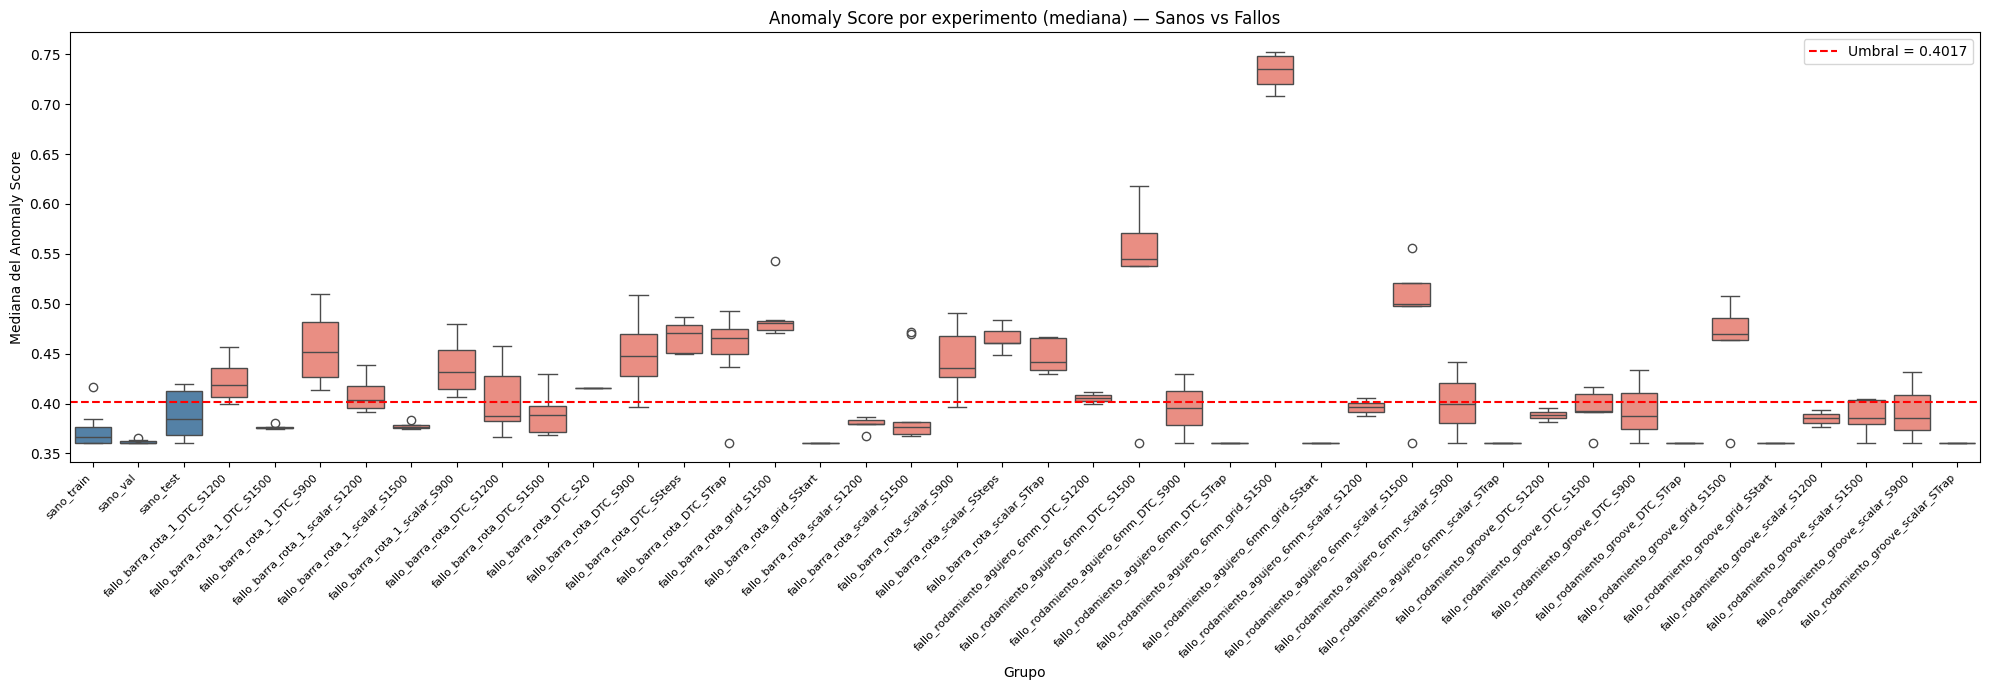

In [13]:

# ============================================================
# 11. BOXPLOT ESTILO PAPER
# ============================================================

df_box = pd.DataFrame(datos_boxplot)

# Orden: train, val, test_sano, luego fallos
grupos_sanos  = ["sano_train", "sano_val", "sano_test"]
grupos_fallos = sorted([n for n in df_box["grupo"].unique() if "fallo" in n])

# Añadir train y val al boxplot
for nombre, scores, n_arch in [
    ("sano_train", scores_train_f, 30),
    ("sano_val",   scores_val_f,   6)
]:
    medianas = agregar_por_experimento(scores, 100)
    for m in medianas:
        datos_boxplot.append({"grupo": nombre, "mediana": m, "es_fallo": False})

df_box = pd.DataFrame(datos_boxplot)
orden  = ["sano_train", "sano_val", "sano_test"] + grupos_fallos

colores = {g: "steelblue" if "sano" in g else "salmon" for g in orden}

plt.figure(figsize=(20, 7))
sns.boxplot(
    data    = df_box[df_box["grupo"].isin(orden)],
    x       = "grupo",
    y       = "mediana",
    order   = orden,
    palette = colores
)
plt.axhline(y=umbral, color="red", linestyle="--", linewidth=1.5,
            label=f"Umbral = {umbral:.4f}")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.title("Anomaly Score por experimento (mediana) — Sanos vs Fallos")
plt.xlabel("Grupo")
plt.ylabel("Mediana del Anomaly Score")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTADOS, "boxplot_resultados.png"), dpi=150)
plt.show()

In [ ]:
# ============================================================
# 12. GRÁFICAS OPTUNA
# ============================================================

print("\nGenerando gráficas Optuna...")

fig1 = vis.plot_optimization_history(study)
fig1.update_layout(title="Evolución del umbral por trial")
fig1.write_html(os.path.join(RUTA_RESULTADOS, "optuna_historia.html"))
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.update_layout(title="Importancia de hiperparámetros")
fig2.write_html(os.path.join(RUTA_RESULTADOS, "optuna_importancia.html"))
fig2.show()

fig3 = vis.plot_parallel_coordinate(study)
fig3.update_layout(title="Coordenadas paralelas")
fig3.write_html(os.path.join(RUTA_RESULTADOS, "optuna_coordenadas.html"))
fig3.show()

fig4 = vis.plot_contour(study, params=["ntrees", "extension_level"])
fig4.update_layout(title="Contour: ntrees vs extension_level")
fig4.write_html(os.path.join(RUTA_RESULTADOS, "optuna_contour.html"))
fig4.show()

print("\n✅ Todo completado.")
print(f"Umbral final: {umbral:.6f}")
h2o.cluster().show_status()